# 1. Data load & imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import warnings
from sklearn.impute import SimpleImputer
import joblib

In [2]:
df = pd.read_csv('../data/auto_ria_clean.csv')
df.head()

,price,mileage,road_accident,release_year,is_electric,engine_volume,region,mark_bucketed_Audi,mark_bucketed_BMW,mark_bucketed_Ford,...,fuel_type_Електро,fuel_type_Не вказано,transmission_Автомат,transmission_Варіатор,transmission_Механічна,transmission_Не вказано,transmission_Не застосовно,transmission_Редуктор,transmission_Робот,transmission_Типтронік
0,23800,18000,0,2022,0,2.0,Сміла,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,29999,133000,1,2017,0,3.0,Львівська,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,25800,12000,0,2022,1,NaN,Київ,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,31500,127000,0,2017,0,2.0,Одеса,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13900,231000,0,2018,0,1.5,Хмельницький,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 2. Linear Regression VS RIDGE VS LASSO VS LightGBM

In [3]:
df = pd.read_csv('../data/auto_ria_clean.csv')

# ── фічі ──────────────────────────────────────────────────────────────
drop_cols = ['region']  # текстова, не закодована — дропаємо
feature_cols = [c for c in df.columns if c != 'price' and c not in drop_cols]

X = df[feature_cols].select_dtypes(include='number')
y = np.log1p(df['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── helper ────────────────────────────────────────────────────────────
def evaluate(name, y_test, y_pred_log):
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_test, y_pred_log)
    print(f'{name}:')
    print(f'  MAE:  ${mae:,.0f}')
    print(f'  RMSE: ${rmse:,.0f}')
    print(f'  R²:   {r2:.3f}\n')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []

def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

# ── 1. Linear Regression ──────────────────────────────────────────────
pipe_lr = make_pipeline(LinearRegression())
pipe_lr.fit(X_train, y_train)
results.append(evaluate('Linear Regression', y_test, pipe_lr.predict(X_test)))

# ── 2. Ridge ──────────────────────────────────────────────────────────
pipe_ridge = make_pipeline(Ridge(alpha=10))
pipe_ridge.fit(X_train, y_train)
results.append(evaluate('Ridge (alpha=10)', y_test, pipe_ridge.predict(X_test)))

# ── 3. Lasso ──────────────────────────────────────────────────────────
pipe_lasso = make_pipeline(Lasso(alpha=0.01))
pipe_lasso.fit(X_train, y_train)
results.append(evaluate('Lasso (alpha=0.01)', y_test, pipe_lasso.predict(X_test)))

# ── 4. LightGBM ───────────────────────────────────────────────────────
lgbm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train,
         eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
results.append(evaluate('LightGBM', y_test, lgbm.predict(X_test)))

# ── 5. Порівняння моделей ─────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('model')
print('\n── Model comparison ──')
print(results_df.round(0))

# ── 6. SHAP для LightGBM ─────────────────────────────────────────────
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

Linear Regression:
  MAE:  $7,616
  RMSE: $18,883
  R²:   0.743

Ridge (alpha=10):
  MAE:  $7,620
  RMSE: $18,904
  R²:   0.742

Lasso (alpha=0.01):
  MAE:  $7,720
  RMSE: $19,322
  R²:   0.738

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.110059
[200]	valid_0's l2: 0.103742
[300]	valid_0's l2: 0.101692
Early stopping, best iteration is:
[331]	valid_0's l2: 0.101316
LightGBM:
  MAE:  $4,694
  RMSE: $9,671
  R²:   0.860


── Model comparison ──
                       MAE     RMSE   R2
model                                   
Linear Regression   7616.0  18883.0  1.0
Ridge (alpha=10)    7620.0  18904.0  1.0
Lasso (alpha=0.01)  7720.0  19322.0  1.0
LightGBM            4694.0   9671.0  1.0


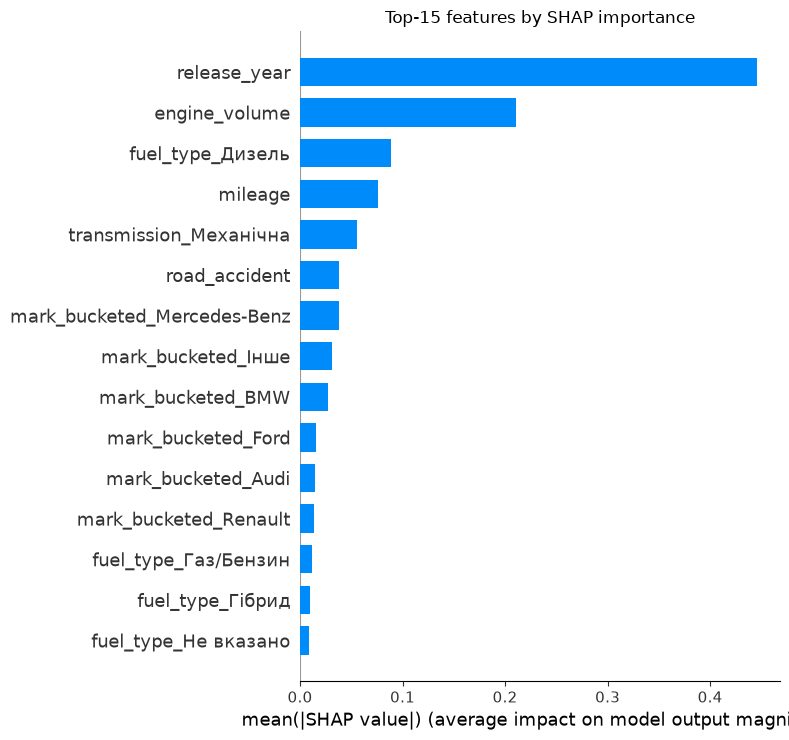

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False,
                  max_display=15)
plt.title('Top-15 features by SHAP importance')
plt.tight_layout()
plt.savefig('../data/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
print(results_df.round({'MAE': 0, 'RMSE': 0, 'R2': 3}))

                       MAE     RMSE     R2
model                                     
Linear Regression   7616.0  18883.0  0.743
Ridge (alpha=10)    7620.0  18904.0  0.742
Lasso (alpha=0.01)  7720.0  19322.0  0.738
LightGBM            4694.0   9671.0  0.860


## Results & Conclusions

| Model | MAE | RMSE | R² |
|-------|-----|------|----|
| Linear Regression | $7,616 | $18,883 | 0.743 |
| Ridge (alpha=10) | $7,620 | $18,904 | 0.742 |
| Lasso (alpha=0.01) | $7,720 | $19,322 | 0.738 |
| LightGBM ✅ | $4,694 | $9,671 | 0.860 |

**LightGBM wins** — MAE twice lower than linear models.  
Linear models plateau at R²≈0.74 because price has non-linear dependencies 
(e.g. year × brand interactions) that trees capture naturally.

**Key SHAP insights:**
- `release_year` is the dominant feature by far — year of manufacture 
  defines the price class more than anything else on the Ukrainian market
- `engine_volume` ranks 2nd — strongly correlated with car segment
- `mileage` ranks only 4th — two similar-year cars with different mileage 
  are priced closer than two different-year cars with similar mileage
- `road_accident` has measurable but moderate impact

In [6]:
joblib.dump(lgbm, 'models/lightgbm.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'models/lightgbm.pkl'